<a href="https://colab.research.google.com/github/elektra773/Final-Project-ECON23050/blob/main/patent_data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [41]:
import pandas as pd
import numpy as np
import re
from pathlib import Path
from google.colab import drive

drive.mount('/content/drive')

DATA_DIR = Path("/content/drive/MyDrive/FinalProject")
OUT_DIR = Path("/content/outputs")
OUT_DIR.mkdir(parents=True, exist_ok=True)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Chunk 2: Keyword dictionaries and regex patterns
This chunk defines the AI terms, therapeutic-area terms, and biological target terms the notebook will search for in patent text. I expanded the AI and target vocabularies and changed the area setup so we can score all areas instead of assigning the first match.

In [42]:
AI_KEYWORDS = [
    "machine learning", "deep learning", "neural network", "neural net",
    "artificial intelligence", "random forest", "support vector machine",
    "support vector machines", "svm", "classifier", "classification model",
    "predictive model", "prediction model", "trained model", "training data",
    "feature selection", "feature extraction", "supervised learning",
    "unsupervised learning", "reinforcement learning", "computer implemented model",
    "computer-implemented model", "algorithmic model", "data-driven model",
]

THERAPEUTIC_AREA_KEYWORDS = {
    "oncology": [
        "cancer", "tumor", "tumour", "carcinoma", "oncology", "neoplasm",
        "leukemia", "lymphoma", "melanoma", "sarcoma", "metastatic",
        "malignancy", "antineoplastic", "anti-cancer", "anticancer"
    ],
    "neurology": [
        "alzheimer", "parkinson", "neurolog", "neurodegenerative", "epilepsy",
        "multiple sclerosis", "dementia", "cns", "central nervous system",
        "seizure", "huntington", "amyotrophic lateral sclerosis", "als",
        "migraine", "anxiety", "depression", "antipsychotic"
    ],
    "cardiovascular": [
        "heart", "cardiac", "cardiovascular", "hypertension", "atherosclerosis",
        "arrhythmia", "myocardial", "vascular", "thrombosis", "ischemia",
        "heart failure", "coronary", "blood pressure", "vasodilator"
    ],
    "immunology": [
        "immune", "immunology", "immunotherapy", "autoimmune", "cytokine",
        "inflammation", "inflammatory", "antibody", "t cell", "b cell",
        "checkpoint inhibitor", "immune response", "immunomodulatory",
        "allergic", "allergy", "immunosuppressive", "immunostimulatory"
    ],
    "infectious_disease": [
        "infection", "infectious", "antiviral", "antibiotic", "bacterial",
        "viral", "fungal", "pathogen", "sepsis", "microbial", "antimicrobial",
        "hiv", "influenza", "coronavirus", "hepatitis", "herpes", "tuberculosis",
        "antiparasitic", "antimalarial"
    ],
    "metabolic_disorders": [
        "diabetes", "metabolic", "obesity", "insulin", "hyperglycemia",
        "dyslipidemia", "cholesterol", "lipid", "fatty liver", "nash",
        "metabolic syndrome", "glucose", "hyperlipidemia", "antidiabetic",
        "glucose homeostasis"
    ],
}

MECHANISM_KEYWORDS = {
    "oncology": [
        "kinase inhibitor", "oncogene", "tumor suppressor", "cell proliferation",
        "apoptosis", "metastasis", "antiproliferative", "dna damage response",
        "synthetic lethality"
    ],
    "neurology": [
        "neuroprotective", "synaptic", "neuron", "neuronal", "neurotransmitter",
        "blood brain barrier", "amyloid", "tau phosphorylation", "dopaminergic"
    ],
    "cardiovascular": [
        "vascular tone", "platelet aggregation", "cardiac hypertrophy",
        "vasodilation", "endothelial dysfunction", "antithrombotic"
    ],
    "immunology": [
        "immune modulation", "immune checkpoint", "cytokine signaling",
        "t cell activation", "antigen presentation", "inflammatory signaling",
        "adaptive immunity", "innate immunity"
    ],
    "infectious_disease": [
        "antimicrobial activity", "viral replication", "bacterial growth",
        "pathogen load", "host-pathogen", "anti-infective"
    ],
    "metabolic_disorders": [
        "glucose homeostasis", "insulin sensitivity", "lipid metabolism",
        "energy balance", "metabolic regulation"
    ],
}

GENERAL_THERAPEUTIC_KEYWORDS = [
    "pharmaceutical composition", "pharmaceutical formulation", "pharmaceutical preparation",
    "therapeutic composition", "therapeutic agent", "therapeutic use", "drug delivery",
    "pharmaceutically acceptable", "compound useful for treating", "method for treating",
    "treatment of a disease", "treatment of a disorder", "therapy for", "medicament",
    "dosage form", "unit dosage", "formulation", "pharmaceutical salt", "salt form",
    "crystalline form", "polymorph", "solvate", "prodrug", "conjugate", "antibody",
    "antigen-binding", "peptide", "small molecule", "nucleic acid", "compound of formula",
    "subject in need thereof",
]

A61P_PREFIX_TO_AREA = {
    "A61P35": "oncology",
    "A61P25": "neurology",
    "A61P9": "cardiovascular",
    "A61P37": "immunology",
    "A61P31": "infectious_disease",
    "A61P33": "infectious_disease",
    "A61P3": "metabolic_disorders",
}

A61P_EXCLUDE_PREFIXES = {
    "A61P1", "A61P5", "A61P7", "A61P11", "A61P13", "A61P15", "A61P17",
    "A61P19", "A61P21", "A61P23", "A61P27", "A61P29", "A61P39",
    "A61P41", "A61P43",
}

AREA_PRIORITY = [
    "oncology",
    "neurology",
    "cardiovascular",
    "immunology",
    "infectious_disease",
    "metabolic_disorders",
]

TARGET_KEYWORDS = {
    "EGFR": [r"\begfr\b", r"\berbb1\b", r"\bepidermal growth factor receptor\b"],
    "ERBB2": [r"\berbb2\b", r"\bher2\b"],
    "KRAS": [r"\bkras\b"],
    "BRAF": [r"\bbraf\b"],
    "VEGF": [r"\bvegf\b", r"\bvegfa\b"],
    "PDCD1": [r"\bpdcd1\b", r"\bpd-?1\b"],
    "CD274": [r"\bcd274\b", r"\bpd-?l1\b"],
    "CTLA4": [r"\bctla-?4\b", r"\bctla4\b"],
    "TNF": [r"\btnf\b", r"\btumou?r necrosis factor\b"],
    "IL6": [r"\bil-?6\b", r"\binterleukin-?6\b"],
    "JAK": [r"\bjak1\b", r"\bjak2\b", r"\bjak3\b", r"\btyk2\b", r"\bjak\b"],
    "PCSK9": [r"\bpcsk9\b"],
    "SGLT2": [r"\bsglt2\b", r"\bslc5a2\b"],
    "DPP4": [r"\bdpp-?4\b"],
    "GLP1R": [r"\bglp-?1r\b"],
    "BACE1": [r"\bbace1\b"],
    "MAPT": [r"\bmapt\b", r"\btau\b"],
    "SNCA": [r"\bsnca\b", r"\balpha-synuclein\b"],
    "LRRK2": [r"\blrrk2\b"],
}

TARGET_TO_AREA = {
    "EGFR": {"oncology": 3},
    "ERBB2": {"oncology": 3},
    "KRAS": {"oncology": 3},
    "BRAF": {"oncology": 3},
    "VEGF": {"oncology": 2, "cardiovascular": 1},
    "PDCD1": {"immunology": 2, "oncology": 2},
    "CD274": {"immunology": 2, "oncology": 2},
    "CTLA4": {"immunology": 2, "oncology": 2},
    "TNF": {"immunology": 3},
    "IL6": {"immunology": 3},
    "JAK": {"immunology": 2},
    "PCSK9": {"cardiovascular": 3},
    "SGLT2": {"metabolic_disorders": 3},
    "DPP4": {"metabolic_disorders": 3},
    "GLP1R": {"metabolic_disorders": 3},
    "BACE1": {"neurology": 3},
    "MAPT": {"neurology": 3},
    "SNCA": {"neurology": 3},
    "LRRK2": {"neurology": 3},
}

AI_PATTERNS = [re.compile(rf"\b{re.escape(term)}\b", flags=re.IGNORECASE) for term in AI_KEYWORDS]
AREA_PATTERNS = {
    area: [re.compile(rf"\b{re.escape(term)}\b", flags=re.IGNORECASE) for term in terms]
    for area, terms in THERAPEUTIC_AREA_KEYWORDS.items()
}
MECHANISM_PATTERNS = {
    area: [re.compile(rf"\b{re.escape(term)}\b", flags=re.IGNORECASE) for term in terms]
    for area, terms in MECHANISM_KEYWORDS.items()
}
GENERAL_THERAPEUTIC_PATTERNS = [
    re.compile(rf"\b{re.escape(term)}\b", flags=re.IGNORECASE)
    for term in GENERAL_THERAPEUTIC_KEYWORDS
]
TARGET_PATTERNS = {
    target: re.compile("|".join(patterns), flags=re.IGNORECASE)
    for target, patterns in TARGET_KEYWORDS.items()
}



Chunk 3: Helper functions
This chunk loads large TSVs in chunks, normalizes patent text, assigns therapeutic areas by score rather than first match, detects AI language, and computes your concentration and entropy measures.

In [43]:
def load_filtered_tsv(path, usecols, ids_df, chunksize=250_000):
    parts = []
    total_rows = 0
    matched_rows = 0

    for i, chunk in enumerate(pd.read_csv(
        path,
        sep="\t",
        usecols=usecols,
        dtype="string",
        chunksize=chunksize,
        low_memory=False,
    ), start=1):
        total_rows += len(chunk)
        chunk = chunk.merge(ids_df, on="patent_id", how="inner")
        matched_rows += len(chunk)

        if not chunk.empty:
            parts.append(chunk)

        if i % 10 == 0:
            print(f"{path.name}: processed {total_rows:,} rows, kept {matched_rows:,}")

    out = pd.concat(parts, ignore_index=True) if parts else pd.DataFrame(columns=usecols)
    print(f"{path.name}: final shape = {out.shape}")
    return out


def normalize_text(series):
    return (
        series.fillna("")
        .astype(str)
        .str.lower()
        .str.replace(r"\s+", " ", regex=True)
        .str.strip()
    )


def detect_ai(text):
    if not text:
        return 0
    return int(any(pattern.search(text) for pattern in AI_PATTERNS))


def choose_primary_area(areas):
    areas = [area for area in areas if area]
    if not areas:
        return pd.NA
    unique_areas = list(dict.fromkeys(areas))
    for area in AREA_PRIORITY:
        if area in unique_areas:
            return area
    return unique_areas[0]


def extract_a61p_codes(code_text):
    if not code_text:
        return []
    text = str(code_text).upper().replace(" ", "")
    return sorted(set(re.findall(r"A61P\d{1,2}(?:/\d{2})?", text)))


def map_a61p_codes_to_areas(code_list):
    areas = []
    excluded = []
    for code in code_list:
        matched = False
        for prefix, area in A61P_PREFIX_TO_AREA.items():
            if code.startswith(prefix):
                areas.append(area)
                matched = True
                break
        if not matched:
            for prefix in A61P_EXCLUDE_PREFIXES:
                if code.startswith(prefix):
                    excluded.append(code)
                    matched = True
                    break
    return list(dict.fromkeys(areas)), excluded


def classify_text_row(row, target_cols):
    text = row["text_for_analysis"]
    scores = {area: 0 for area in THERAPEUTIC_AREA_KEYWORDS}

    for area, patterns in AREA_PATTERNS.items():
        scores[area] += 2 * sum(bool(pattern.search(text)) for pattern in patterns)

    for area, patterns in MECHANISM_PATTERNS.items():
        scores[area] += sum(bool(pattern.search(text)) for pattern in patterns)

    for target in target_cols:
        if row[target] == 1 and target in TARGET_TO_AREA:
            for area, weight in TARGET_TO_AREA[target].items():
                scores[area] += weight

    best_area = max(scores, key=scores.get)
    if scores[best_area] > 0:
        return best_area

    if any(pattern.search(text) for pattern in GENERAL_THERAPEUTIC_PATTERNS):
        return "general_therapeutic"

    return "unclassified"


def compute_entropy(group):
    target_counts = group[list(TARGET_KEYWORDS)].sum(axis=0)
    total_mentions = float(target_counts.sum())
    if total_mentions == 0:
        return 0.0
    shares = target_counts[target_counts > 0] / total_mentions
    return float(-(shares * np.log(shares)).sum())


def compute_top4_share(group):
    firm_counts = (
        group.dropna(subset=["assignee_id"])
        .groupby("assignee_id")
        .size()
        .sort_values(ascending=False)
    )
    if firm_counts.empty:
        return 0.0
    return float(firm_counts.head(4).sum() / len(group))


Chunk 4: Identify pharmaceutical patents using CPC A61K
This chunk reads the huge CPC file in pieces and keeps only the patent IDs that belong to pharmaceutical patents.

In [44]:
CACHE_DIR = Path("/content/drive/MyDrive/FinalProject/cache")
CACHE_DIR.mkdir(parents=True, exist_ok=True)

a61k_ids_path = CACHE_DIR / "a61k_ids.csv"
a61p_map_path = CACHE_DIR / "a61p_patent_areas.csv"

if a61k_ids_path.exists() and a61p_map_path.exists():
    a61k_df = pd.read_csv(a61k_ids_path, dtype="string", low_memory=False)
    a61p_map = pd.read_csv(a61p_map_path, dtype="string", low_memory=False)
    print("Loaded cached A61K ids and A61P map.")
else:
    cpc_path = DATA_DIR / "g_cpc_current.tsv"
    cpc_header = pd.read_csv(cpc_path, sep="\t", nrows=0)
    cpc_cols = cpc_header.columns.tolist()

    code_cols = [c for c in [
        "cpc_subgroup_id", "cpc_subgroup", "cpc_group_id", "cpc_group",
        "cpc_class_id", "cpc_class", "cpc_type"
    ] if c in cpc_cols]

    usecols = ["patent_id", "cpc_subclass"] + code_cols

    a61k_ids = set()
    a61p_records = []

    for chunk in pd.read_csv(
        cpc_path,
        sep="\t",
        usecols=usecols,
        dtype="string",
        chunksize=1_000_000,
        low_memory=False,
    ):
        chunk["cpc_subclass"] = chunk["cpc_subclass"].str.upper()

        a61k_keep = chunk.loc[chunk["cpc_subclass"] == "A61K", "patent_id"].dropna()
        a61k_ids.update(a61k_keep.tolist())

        a61p_chunk = chunk.loc[chunk["cpc_subclass"] == "A61P"].copy()
        if not a61p_chunk.empty:
            a61p_chunk["code_text"] = a61p_chunk[code_cols].fillna("").agg(" ".join, axis=1)
            a61p_chunk["a61p_codes"] = a61p_chunk["code_text"].apply(extract_a61p_codes)

            for patent_id, code_list in zip(a61p_chunk["patent_id"], a61p_chunk["a61p_codes"]):
                areas, excluded = map_a61p_codes_to_areas(code_list)
                if areas or excluded:
                    a61p_records.append({
                        "patent_id": patent_id,
                        "a61p_codes": ";".join(code_list),
                        "a61p_area_list": ";".join(areas),
                        "a61p_excluded_codes": ";".join(excluded),
                        "therapeutic_area_cpc": choose_primary_area(areas),
                    })

    a61k_df = pd.DataFrame({"patent_id": pd.Series(list(a61k_ids), dtype="string")})

    a61p_map = pd.DataFrame(a61p_records).drop_duplicates(subset=["patent_id"])
    a61p_map = a61p_map.merge(a61k_df, on="patent_id", how="inner")

    a61k_df.to_csv(a61k_ids_path, index=False)
    a61p_map.to_csv(a61p_map_path, index=False)
    print("Built and cached A61K ids and A61P map.")

print(a61k_df.shape, a61p_map.shape)



Loaded cached A61K ids and A61P map.
(308048, 1) (174537, 5)


Chunk 5: Load only the needed rows and columns from each input table
This chunk avoids crashing Colab by reading only the columns you need and only for the pharmaceutical patents you already identified. 5 min chunk

In [45]:
patent_cache = CACHE_DIR / "patent_filtered.csv"
application_cache = CACHE_DIR / "application_filtered.csv"
abstract_cache = CACHE_DIR / "abstract_filtered.csv"
assignee_cache = CACHE_DIR / "assignee_filtered.csv"

if all(path.exists() for path in [patent_cache, application_cache, abstract_cache, assignee_cache]):
    patent = pd.read_csv(patent_cache, dtype="string", low_memory=False)
    application = pd.read_csv(application_cache, dtype="string", low_memory=False)
    abstract = pd.read_csv(abstract_cache, dtype="string", low_memory=False)
    assignee = pd.read_csv(assignee_cache, dtype="string", low_memory=False)
    print("Loaded cached filtered tables.")
else:
    patent = load_filtered_tsv(DATA_DIR / "g_patent.tsv", ["patent_id", "patent_date", "patent_title"], a61k_df)
    application = load_filtered_tsv(DATA_DIR / "g_application.tsv", ["patent_id", "filing_date"], a61k_df)
    abstract = load_filtered_tsv(DATA_DIR / "g_patent_abstract.tsv", ["patent_id", "patent_abstract"], a61k_df)
    assignee = load_filtered_tsv(
        DATA_DIR / "g_assignee_disambiguated.tsv",
        ["patent_id", "assignee_sequence", "assignee_id", "disambig_assignee_organization"],
        a61k_df,
    )

    patent.to_csv(patent_cache, index=False)
    application.to_csv(application_cache, index=False)
    abstract.to_csv(abstract_cache, index=False)
    assignee.to_csv(assignee_cache, index=False)
    print("Built and cached filtered tables.")

print(patent.shape, application.shape, abstract.shape, assignee.shape)



Loaded cached filtered tables.
(308048, 3) (308048, 2) (308048, 2) (321354, 4)


Chunk 6: Keep one assignee per patent and merge the core patent-level dataset
This chunk keeps the primary assignee only, then merges patent, application, abstract, and assignee information into one patent-level table.

In [46]:
merged_cache = CACHE_DIR / "merged_patent_df_with_cpc.csv"

if merged_cache.exists():
    df = pd.read_csv(merged_cache, low_memory=False)
    df["filing_date"] = pd.to_datetime(df["filing_date"], errors="coerce")
    df["patent_date"] = pd.to_datetime(df["patent_date"], errors="coerce")
    print("Loaded cached merged dataframe:", df.shape)
else:
    assignee["assignee_sequence"] = pd.to_numeric(assignee["assignee_sequence"], errors="coerce")
    assignee = assignee[assignee["assignee_sequence"] == 0].copy()
    assignee = assignee.rename(columns={"disambig_assignee_organization": "assignee_name"})
    assignee = assignee.drop_duplicates(subset=["patent_id"])

    df = patent.merge(application, on="patent_id", how="left")
    df = df.merge(abstract, on="patent_id", how="left")
    df = df.merge(assignee[["patent_id", "assignee_id", "assignee_name"]], on="patent_id", how="left")
    df = df.merge(a61p_map, on="patent_id", how="left")

    df["filing_date"] = pd.to_datetime(df["filing_date"], errors="coerce")
    df["patent_date"] = pd.to_datetime(df["patent_date"], errors="coerce")
    df["filing_year"] = df["filing_date"].dt.year

    df.to_csv(merged_cache, index=False)
    print("Built and cached merged dataframe:", df.shape)

df.head()




Built and cached merged dataframe: (308048, 12)


,patent_id,patent_date,patent_title,filing_date,patent_abstract,assignee_id,assignee_name,a61p_codes,a61p_area_list,a61p_excluded_codes,therapeutic_area_cpc,filing_year
0,10000395,2018-06-19,High-magnesium concentrated liquid and high-ma...,2016-09-27,A high-magnesium concentrated liquid is disclo...,9f801dbc-f659-4209-be89-046c98aa4339,"Quality Pure Co., Ltd.",<NA>,<NA>,<NA>,<NA>,2016
1,10000438,2018-06-19,Small molecule inhibitors of TRPA1,2016-08-02,The present invention relates to the use of co...,952fa920-ca62-46b6-9e63-d7789911d2d2,B.R.A.I.N. Biotechnology Research and Informat...,A61P17/00,<NA>,A61P17/00,<NA>,2016
2,10000443,2018-06-19,Compositions and methods for glucose transport...,2015-11-09,Glucose deprivation is an attractive strategy ...,6c206349-d7f6-44a4-81c2-cf38a2e5025a,Ohio University,A61P35/00,oncology,<NA>,oncology,2015
3,10000445,2018-06-19,Stable crystal modifications of DOTAP chloride,2012-05-02,The present invention relates to crystal modif...,acbd187a-e9af-43d4-bfec-20baae360619,Merck Patent GmbH,A61P17/00,<NA>,A61P17/00,<NA>,2012
4,10000447,2018-06-19,Compounds for targeting drug delivery and enha...,2016-06-08,Here described are compounds consisting of the...,a7061663-7fca-4bc6-a0ce-a51ec067f298,NITTO DENKO CORPORATION,A61P1/16,<NA>,A61P1/16,<NA>,2016


Chunk 7: Create AI, therapeutic-area, and biological-target features
This chunk turns raw text into the core variables for your analysis. It builds one text field, flags AI patents, assigns a therapeutic area, and creates one binary column per biological target.

In [47]:
target_ready_cache = CACHE_DIR / "df_with_targets_and_cpc.csv"
classified_cache = CACHE_DIR / "df_classified_with_cpc.csv"
target_cols = list(TARGET_KEYWORDS.keys())

if target_ready_cache.exists():
    df = pd.read_csv(target_ready_cache, low_memory=False)
    print("Loaded cached target-ready dataframe:", df.shape)
else:
    df["text_for_analysis"] = normalize_text(
        df["patent_abstract"].fillna("") + " " + df["patent_title"].fillna("")
    )

    df["AI_patent"] = df["text_for_analysis"].apply(detect_ai).astype("int8")

    for target, pattern in TARGET_PATTERNS.items():
        df[target] = df["text_for_analysis"].str.contains(pattern, na=False).astype("int8")

    df["any_target"] = (df[target_cols].sum(axis=1) > 0).astype("int8")

    df.to_csv(target_ready_cache, index=False)
    print("Built and cached target-ready dataframe:", df.shape)

if classified_cache.exists():
    df = pd.read_csv(classified_cache, low_memory=False)
    print("Loaded cached classified dataframe:", df.shape)
else:
    missing_cpc = df["therapeutic_area_cpc"].isna()

    df["therapeutic_area_text"] = pd.NA
    df.loc[missing_cpc, "therapeutic_area_text"] = (
        df.loc[missing_cpc, ["text_for_analysis"] + target_cols]
        .apply(lambda row: classify_text_row(row, target_cols), axis=1)
    )

    df["therapeutic_area"] = df["therapeutic_area_cpc"].fillna(df["therapeutic_area_text"])
    df["therapeutic_area_source"] = np.where(
        df["therapeutic_area_cpc"].notna(),
        "A61P",
        np.where(df["therapeutic_area_text"].notna(), "text_fallback", "unclassified")
    )

    df.to_csv(classified_cache, index=False)
    print("Built and cached classified dataframe:", df.shape)

df.head()



Built and cached target-ready dataframe: (308048, 34)
Built and cached classified dataframe: (308048, 37)


,patent_id,patent_date,patent_title,filing_date,patent_abstract,assignee_id,assignee_name,a61p_codes,a61p_area_list,a61p_excluded_codes,...,DPP4,GLP1R,BACE1,MAPT,SNCA,LRRK2,any_target,therapeutic_area_text,therapeutic_area,therapeutic_area_source
0,10000395,2018-06-19,High-magnesium concentrated liquid and high-ma...,2016-09-27,A high-magnesium concentrated liquid is disclo...,9f801dbc-f659-4209-be89-046c98aa4339,"Quality Pure Co., Ltd.",<NA>,<NA>,<NA>,...,0,0,0,0,0,0,0,unclassified,unclassified,text_fallback
1,10000438,2018-06-19,Small molecule inhibitors of TRPA1,2016-08-02,The present invention relates to the use of co...,952fa920-ca62-46b6-9e63-d7789911d2d2,B.R.A.I.N. Biotechnology Research and Informat...,A61P17/00,<NA>,A61P17/00,...,0,0,0,0,0,0,0,general_therapeutic,general_therapeutic,text_fallback
2,10000443,2018-06-19,Compositions and methods for glucose transport...,2015-11-09,Glucose deprivation is an attractive strategy ...,6c206349-d7f6-44a4-81c2-cf38a2e5025a,Ohio University,A61P35/00,oncology,<NA>,...,0,0,0,0,0,0,0,<NA>,oncology,A61P
3,10000445,2018-06-19,Stable crystal modifications of DOTAP chloride,2012-05-02,The present invention relates to crystal modif...,acbd187a-e9af-43d4-bfec-20baae360619,Merck Patent GmbH,A61P17/00,<NA>,A61P17/00,...,0,0,0,0,0,0,0,unclassified,unclassified,text_fallback
4,10000447,2018-06-19,Compounds for targeting drug delivery and enha...,2016-06-08,Here described are compounds consisting of the...,a7061663-7fca-4bc6-a0ce-a51ec067f298,NITTO DENKO CORPORATION,A61P1/16,<NA>,A61P1/16,...,0,0,0,0,0,0,0,general_therapeutic,general_therapeutic,text_fallback


7B

Chunk 8: Diagnostics to check whether classification is too strict or too noisy
This chunk helps you inspect the quality of the AI, area, and target assignments before you build the final panel.

In [48]:
print("AI share:", df["AI_patent"].mean())
print("Share with at least one target:", df["any_target"].mean())

print("\nTherapeutic area distribution:")
print(df["therapeutic_area"].value_counts(dropna=False).head(20))

print("\nTherapeutic area source:")
print(df["therapeutic_area_source"].value_counts(dropna=False))

print("\nShare classified by A61P:")
print(df["therapeutic_area_cpc"].notna().mean())

print("\nTop A61P codes:")
print(
    df["a61p_codes"].dropna().str.split(";").explode().value_counts().head(20)
)

print("\nSample A61P-classified patents:")
display(
    df.loc[
        df["therapeutic_area_source"] == "A61P",
        ["patent_id", "therapeutic_area", "a61p_codes", "patent_title"]
    ].head(10)
)

print("\nSample text-fallback patents:")
display(
    df.loc[
        df["therapeutic_area_source"] == "text_fallback",
        ["patent_id", "therapeutic_area", "patent_title", "patent_abstract"]
    ].head(10)
)

print("\nSample remaining unclassified patents:")
display(
    df.loc[
        df["therapeutic_area"].isna() | (df["therapeutic_area"] == "unclassified"),
        ["patent_id", "patent_title", "patent_abstract"]
    ].head(10)
)


AI share: 0.0001850360982703994
Share with at least one target: 0.02473965096348621

Therapeutic area distribution:
therapeutic_area
unclassified           105066
oncology                42271
infectious_disease      37709
general_therapeutic     34276
immunology              25983
metabolic_disorders     25406
neurology               19698
cardiovascular          17639
Name: count, dtype: Int64

Therapeutic area source:
therapeutic_area_source
text_fallback    210119
A61P              97929
Name: count, dtype: int64

Share classified by A61P:
0.31790175557056044

Top A61P codes:
a61p_codes
A61P35/00    26675
A61P1/00     11779
A61P25/00     6696
A61P31/04     6604
A61P17/00     6501
A61P9/00      6191
A61P1/04      5695
A61P3/00      5546
A61P1/16      5143
A61P3/10      4493
A61P31/00     4392
A61P31/12     4345
A61P11/00     3944
A61P29/00     3823
A61P7/00      3145
A61P3/04      2952
A61P27/02     2798
A61P43/00     2794
A61P1/02      2744
A61P9/10      2565
Name: count, dtype: in

,patent_id,therapeutic_area,a61p_codes,patent_title
2,10000443,oncology,A61P35/00,Compositions and methods for glucose transport...
6,10000451,oncology,A61P35/00,MAP4K4 (HGK) inhibitors
7,10000454,metabolic_disorders,A61P3/10,Antidiabetic tricyclic compounds
15,10000478,oncology,A61P35/00,Pyrazol-3-ones that activate pro-apoptotic BAX
17,10000482,neurology,A61P25/00,Kinase inhibitors
19,10000486,infectious_disease,A61P31/12,Antiviral drugs for treatment of arenavirus in...
21,10000490,oncology,A61P35/00,Inhibitors of the fibroblast growth factor rec...
29,10000508,infectious_disease,A61P31/18,"Crystalline dimethyl 3-(benzyloxy)-1-(2,2-dime..."
32,10000521,oncology,A61P35/00,Substituted gemcitabine bicyclic amide analogs...
33,10000523,infectious_disease,A61P31/14,β-D-2′-deoxy-2′-α-fluoro-2′-β-C-substituted-2-...



Sample text-fallback patents:


,patent_id,therapeutic_area,patent_title,patent_abstract
0,10000395,unclassified,High-magnesium concentrated liquid and high-ma...,A high-magnesium concentrated liquid is disclo...
1,10000438,general_therapeutic,Small molecule inhibitors of TRPA1,The present invention relates to the use of co...
3,10000445,unclassified,Stable crystal modifications of DOTAP chloride,The present invention relates to crystal modif...
4,10000447,general_therapeutic,Compounds for targeting drug delivery and enha...,Here described are compounds consisting of the...
5,10000449,immunology,Bisarylsulfonamides useful in the treatment of...,A compound of formula (I) useful for the treat...
8,10000459,cardiovascular,Heterocyclic compounds useful in the treatment...,Heterocyclic compounds are described that are ...
9,10000463,general_therapeutic,Halogen-substituted heterocyclic compound,A novel α-halogen-substituted thiophene compou...
10,10000465,unclassified,Antifungal compound process,The present invention relates to a process for...
11,10000467,unclassified,Cyanine compounds,Compounds used as labels with properties compa...
12,10000468,unclassified,Pyrazines as modulators of GPR6,The present invention provides compounds of fo...



Sample remaining unclassified patents:


,patent_id,patent_title,patent_abstract
0,10000395,High-magnesium concentrated liquid and high-ma...,A high-magnesium concentrated liquid is disclo...
3,10000445,Stable crystal modifications of DOTAP chloride,The present invention relates to crystal modif...
10,10000465,Antifungal compound process,The present invention relates to a process for...
11,10000467,Cyanine compounds,Compounds used as labels with properties compa...
12,10000468,Pyrazines as modulators of GPR6,The present invention provides compounds of fo...
16,10000481,"1H-pyrrolo[2,3-B] pyridine derivatives and the...",The inventions relates to compounds of (I) and...
22,10000496,Compositions useful for treating disorders rel...,Compounds and compositions useful for treating...
25,10000500,Coelenterazine analogues,"Described are coelenterazine analogs, methods ..."
26,10000502,Substituted thiohydantoin derivatives as andro...,"Disclosed are compounds, compositions and meth..."
30,10000510,Salt forms of ceftolozane,This disclosure relates to salt forms of cefto...


Chunk 9: Compute firm age and young-firm status
This chunk finds the first year each assignee appears in the patent data, then calculates firm age and flags young firms as age 5 or less.

In [49]:
first_year = (
    df.dropna(subset=["assignee_id", "filing_year"])
      .groupby("assignee_id")["filing_year"]
      .min()
      .rename("first_year")
)

df = df.merge(first_year, on="assignee_id", how="left")
df["firm_age"] = df["filing_year"] - df["first_year"]
df["young_firm"] = (df["firm_age"].notna() & df["firm_age"].le(5)).astype("int8")

patent_level = df[
    [
        "patent_id", "filing_date", "filing_year", "patent_date",
        "patent_title", "patent_abstract", "assignee_id", "assignee_name",
        "AI_patent", "therapeutic_area", "therapeutic_area_source",
        "therapeutic_area_cpc", "therapeutic_area_text",
        "a61p_codes", "a61p_area_list", "a61p_excluded_codes",
        "first_year", "firm_age", "young_firm", "any_target",
    ] + target_cols
].copy()

records = []

for (area, year), group in patent_level.dropna(subset=["filing_year", "therapeutic_area"]).groupby(["therapeutic_area", "filing_year"]):
    row = {
        "therapeutic_area": area,
        "year": int(year),
        "total_patents": int(len(group)),
        "AI_share": float(group["AI_patent"].mean()),
        "young_firm_share": float(group["young_firm"].mean()),
        "concentration": compute_top4_share(group),
        "entropy": compute_entropy(group),
        "targeted_patent_share": float(group["any_target"].mean()),
        "cpc_classified_share": float(group["therapeutic_area_source"].eq("A61P").mean()),
    }
    for target in target_cols:
        row[f"{target}_share"] = float(group[target].mean())
    records.append(row)

panel = pd.DataFrame(records).sort_values(["therapeutic_area", "year"]).reset_index(drop=True)

patent_level.to_csv(OUT_DIR / "patent_level_dataset.csv", index=False)
panel.to_csv(OUT_DIR / "area_year_panel.csv", index=False)

print("Saved:", OUT_DIR / "patent_level_dataset.csv")
print("Saved:", OUT_DIR / "area_year_panel.csv")



Saved: /content/outputs/patent_level_dataset.csv
Saved: /content/outputs/area_year_panel.csv


In [50]:
from pathlib import Path
import shutil

src = Path("/content/outputs")
dst = Path("/content/drive/MyDrive/FinalProject/outputs")
dst.mkdir(parents=True, exist_ok=True)

for file in src.iterdir():
    if file.is_file():
        shutil.copy2(file, dst / file.name)

print("Copied files to:", dst)
print(list(dst.iterdir()))


Copied files to: /content/drive/MyDrive/FinalProject/outputs
[PosixPath('/content/drive/MyDrive/FinalProject/outputs/patent_level_dataset.csv'), PosixPath('/content/drive/MyDrive/FinalProject/outputs/area_year_panel.csv')]


# New section

Setup

In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.figsize"] = (10, 6)

AREA_LABELS = {
    "oncology": "Oncology",
    "neurology": "Neurology",
    "cardiovascular": "Cardiovascular",
    "immunology": "Immunology",
    "infectious_disease": "Infectious Disease",
    "metabolic_disorders": "Metabolic Disorders",
    "unclassified": "Unclassified",
}

target_cols = [c for c in patent_level.columns if c in [
    "EGFR","ERBB2","HER3","KRAS","NRAS","HRAS","BRAF","RAF1","MEK","ERK","PIK3CA","AKT",
    "MTOR","PTEN","TP53","BRCA","PARP","VEGF","VEGFR","PDCD1","CD274","CTLA4","TNF",
    "IL6","IL1B","JAK","STAT3","NFKB","TGFB","IFNG","CD19","BCMA","DLL3","ALK","ROS1",
    "RET","FGFR","KIT","FLT3","BTK","BCL2","MCL1","CDK4_6","HSP90","PROTEASOME","PCSK9",
    "SGLT2","DPP4","GLP1R","PPARG","BACE1","MAPT","SNCA","LRRK2"
]]

yearly_patents = patent_level.dropna(subset=["filing_year"]).groupby("filing_year").size().reset_index(name="patents")
area_counts = patent_level["therapeutic_area"].value_counts().rename_axis("area").reset_index(name="patents")
firm_counts = patent_level["assignee_name"].fillna("Unknown").value_counts().head(10).rename_axis("firm").reset_index(name="patents")
yearly_ai = patent_level.dropna(subset=["filing_year"]).groupby("filing_year")["AI_patent"].mean().reset_index(name="AI_share")
yearly_young = patent_level.dropna(subset=["filing_year"]).groupby("filing_year")["young_firm"].mean().reset_index(name="young_firm_share")

area_ai_rank = panel.groupby("therapeutic_area")["AI_share"].mean().mean()
high_ai_areas = panel.groupby("therapeutic_area")["AI_share"].mean().loc[lambda s: s >= s.median()].index.tolist()
panel["ai_group"] = np.where(panel["therapeutic_area"].isin(high_ai_areas), "High AI", "Low AI")


Figure 1: Pharmaceutical Patents Over Time
This plots the total number of A61K patents by filing year.

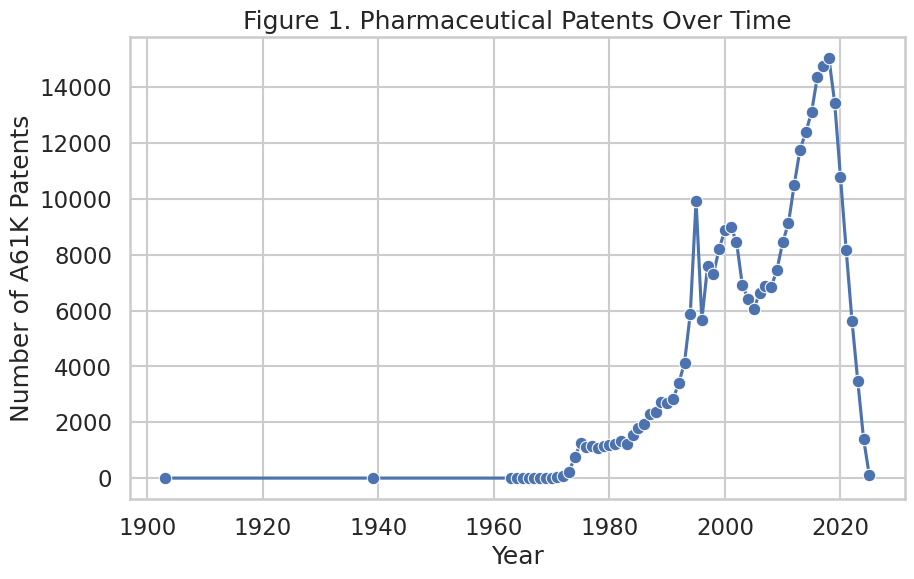

In [52]:
plt.figure()
sns.lineplot(data=yearly_patents, x="filing_year", y="patents", marker="o")
plt.title("Figure 1. Pharmaceutical Patents Over Time")
plt.xlabel("Year")
plt.ylabel("Number of A61K Patents")
plt.show()


Figure 2: Distribution of Patents Across Therapeutic Areas
This shows which therapeutic areas dominate the patent sample.

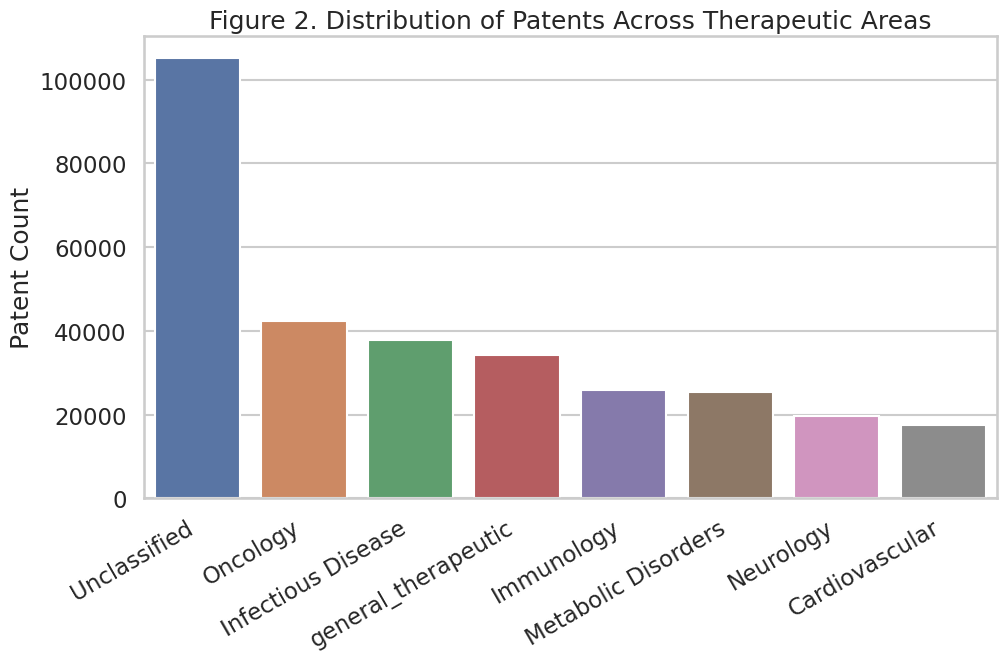

In [53]:
fig2 = area_counts.copy()
fig2["area_label"] = fig2["area"].map(AREA_LABELS).fillna(fig2["area"])
plt.figure(figsize=(11, 6))
sns.barplot(data=fig2, x="area_label", y="patents", hue="area_label", dodge=False, legend=False)
plt.title("Figure 2. Distribution of Patents Across Therapeutic Areas")
plt.xlabel("")
plt.ylabel("Patent Count")
plt.xticks(rotation=30, ha="right")
plt.show()


Figure 3: Top Patent-Producing Firms
This shows the top 10 assignees by patent count.

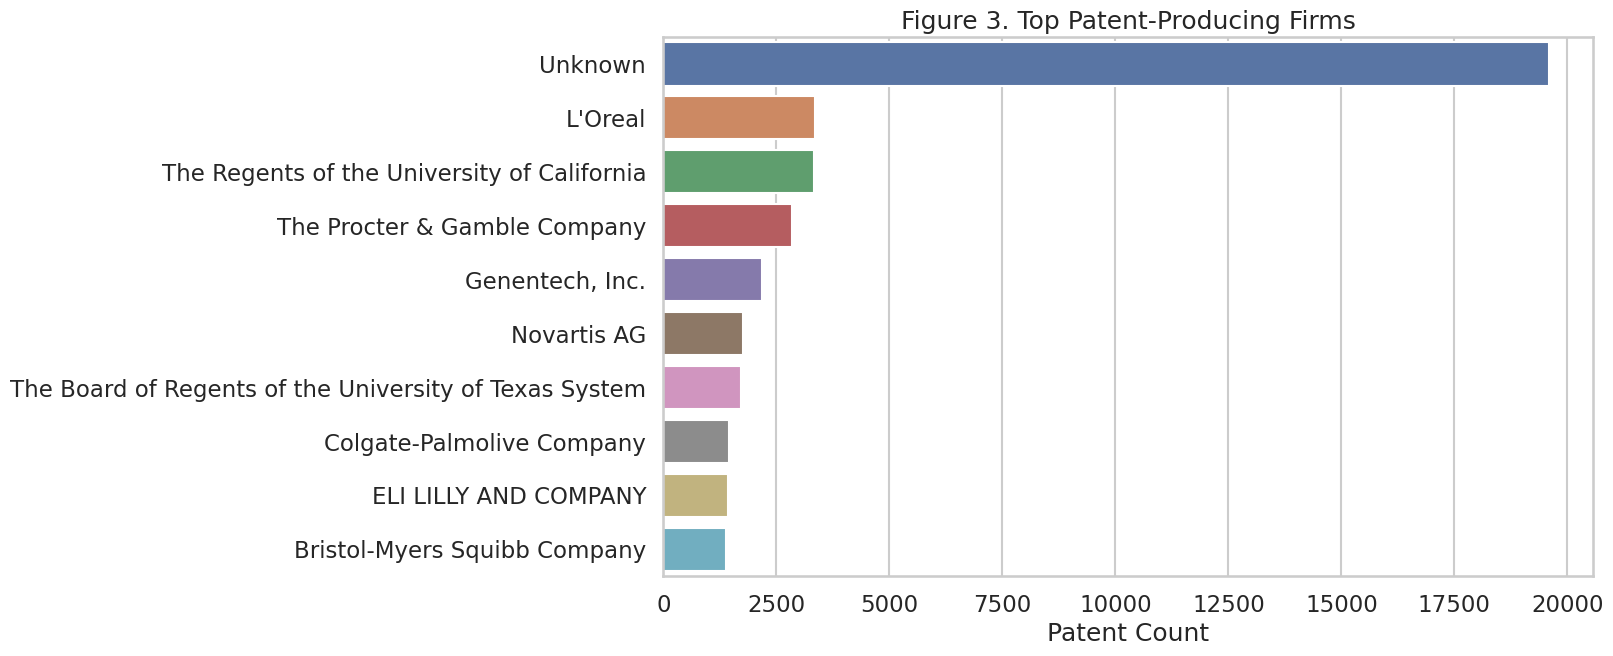

In [54]:
plt.figure(figsize=(12, 7))
sns.barplot(data=firm_counts, y="firm", x="patents", hue="firm", dodge=False, legend=False)
plt.title("Figure 3. Top Patent-Producing Firms")
plt.xlabel("Patent Count")
plt.ylabel("")
plt.show()


Figure 4: Share of AI-Related Patents Over Time
This plots AI patent share by year.

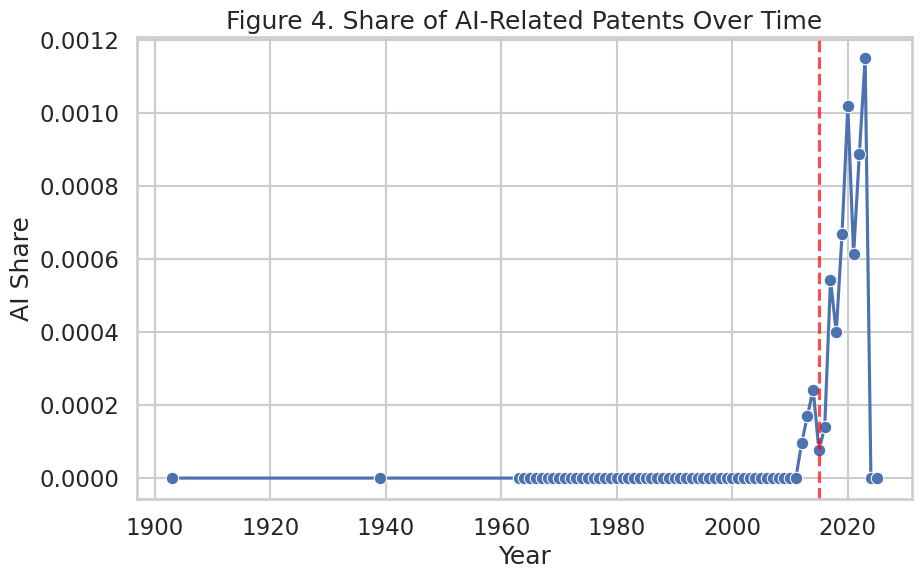

In [55]:
plt.figure()
sns.lineplot(data=yearly_ai, x="filing_year", y="AI_share", marker="o")
plt.axvline(2015, color="red", linestyle="--", alpha=0.7)
plt.title("Figure 4. Share of AI-Related Patents Over Time")
plt.xlabel("Year")
plt.ylabel("AI Share")
plt.show()


Figure 5: AI Adoption by Therapeutic Area
This compares AI adoption over time across therapeutic areas.



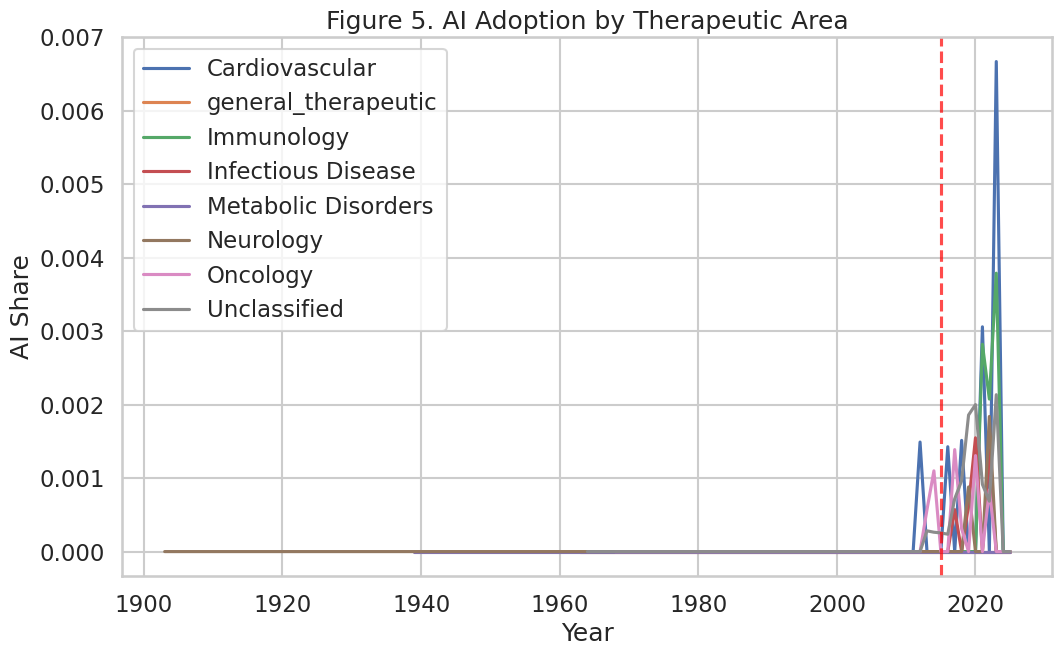

In [56]:
fig5 = panel.copy()
fig5["area_label"] = fig5["therapeutic_area"].map(AREA_LABELS).fillna(fig5["therapeutic_area"])
plt.figure(figsize=(12, 7))
sns.lineplot(data=fig5, x="year", y="AI_share", hue="area_label")
plt.axvline(2015, color="red", linestyle="--", alpha=0.7)
plt.title("Figure 5. AI Adoption by Therapeutic Area")
plt.xlabel("Year")
plt.ylabel("AI Share")
plt.legend(title="")
plt.show()


Figure 6: Heatmap of AI Exposure
This visualizes AI share by area and year.

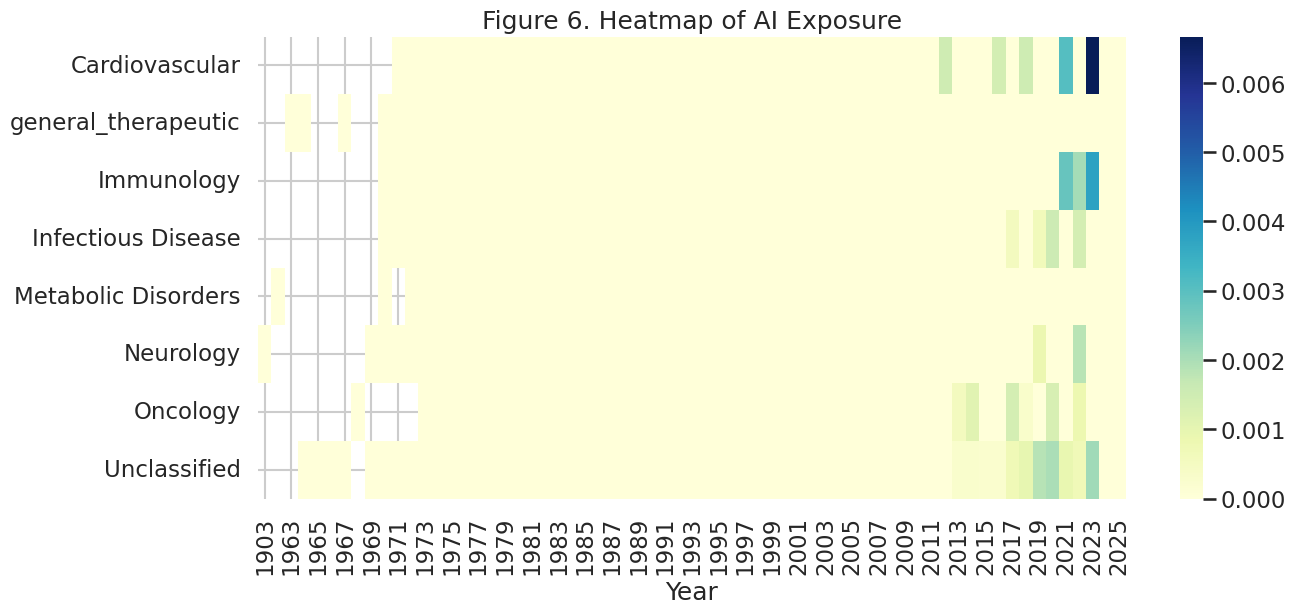

In [57]:
fig6 = panel.pivot(index="therapeutic_area", columns="year", values="AI_share").sort_index()
fig6.index = [AREA_LABELS.get(i, i) for i in fig6.index]
plt.figure(figsize=(14, 6))
sns.heatmap(fig6, cmap="YlGnBu")
plt.title("Figure 6. Heatmap of AI Exposure")
plt.xlabel("Year")
plt.ylabel("")
plt.show()


Figure 7: Target Diversity Over Time
This shows average entropy by year.

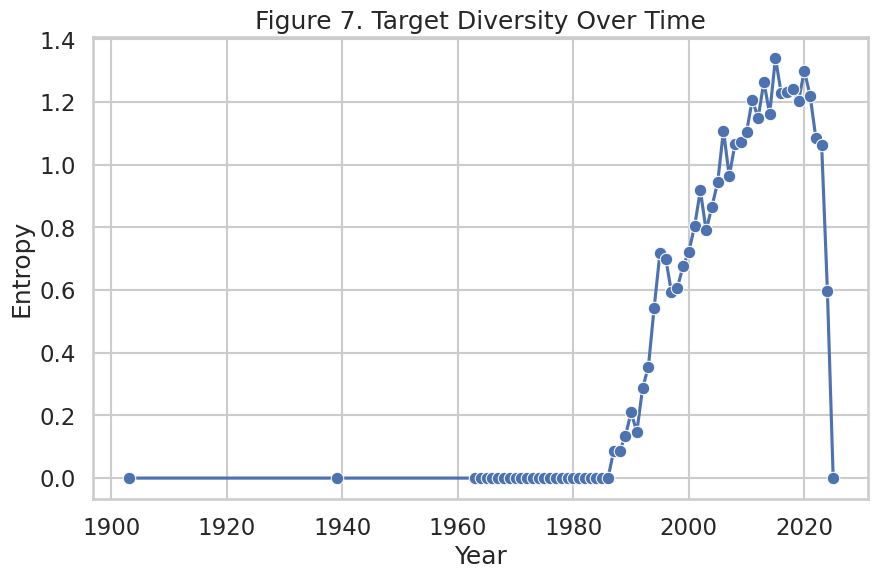

In [58]:
fig7 = panel.groupby("year")["entropy"].mean().reset_index()
plt.figure()
sns.lineplot(data=fig7, x="year", y="entropy", marker="o")
plt.title("Figure 7. Target Diversity Over Time")
plt.xlabel("Year")
plt.ylabel("Entropy")
plt.show()


Figure 8: Target Diversity by Therapeutic Area
This compares entropy trends across therapeutic areas.

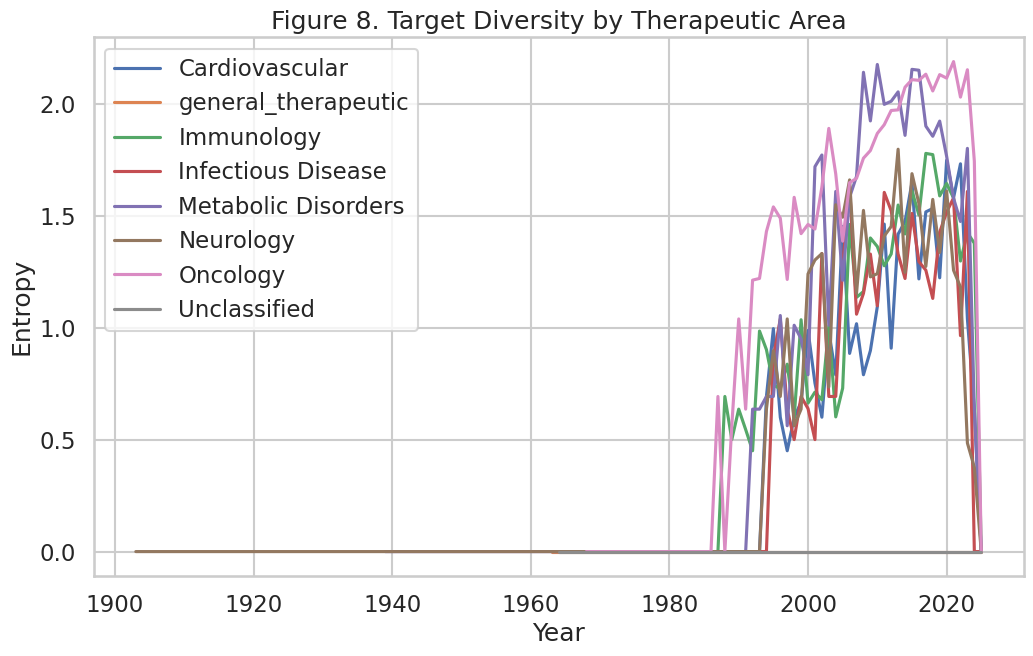

In [59]:
fig8 = panel.copy()
fig8["area_label"] = fig8["therapeutic_area"].map(AREA_LABELS).fillna(fig8["therapeutic_area"])
plt.figure(figsize=(12, 7))
sns.lineplot(data=fig8, x="year", y="entropy", hue="area_label")
plt.title("Figure 8. Target Diversity by Therapeutic Area")
plt.xlabel("Year")
plt.ylabel("Entropy")
plt.legend(title="")
plt.show()


Figure 9: Most Common Biological Targets
This shows the top biological targets by patent frequency.

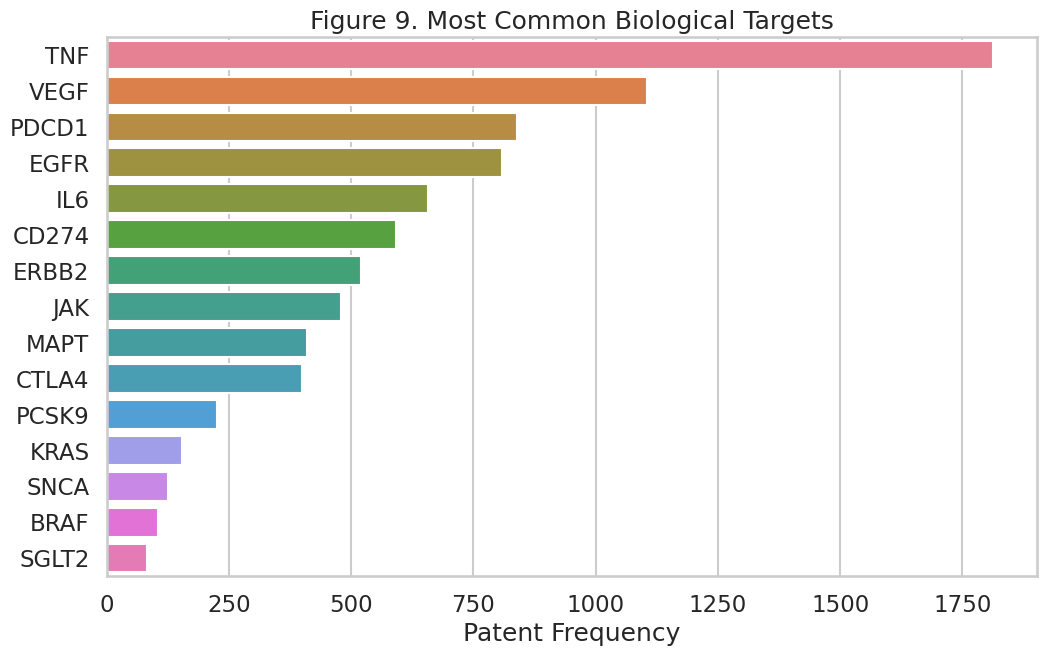

In [60]:
fig9 = patent_level[target_cols].sum().sort_values(ascending=False).head(15).reset_index()
fig9.columns = ["target", "patents"]
plt.figure(figsize=(12, 7))
sns.barplot(data=fig9, y="target", x="patents", hue="target", dodge=False, legend=False)
plt.title("Figure 9. Most Common Biological Targets")
plt.xlabel("Patent Frequency")
plt.ylabel("")
plt.show()


Figure 10: Concentration of Biological Targets
This shows how target shares evolve for the top targets.

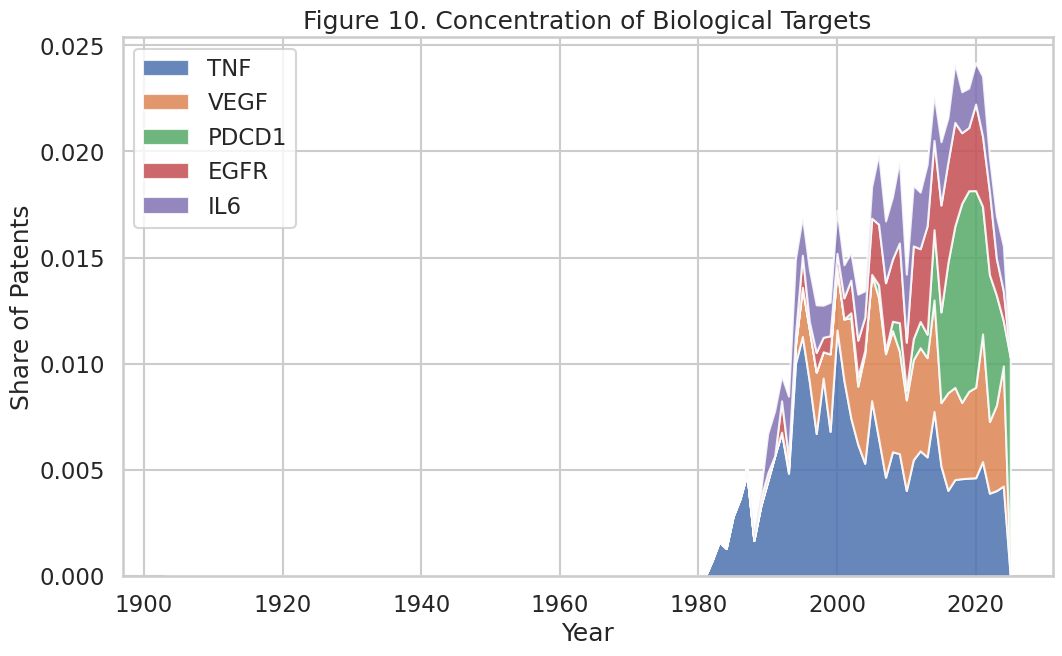

In [61]:
top_targets = patent_level[target_cols].sum().sort_values(ascending=False).head(5).index.tolist()
fig10 = patent_level.dropna(subset=["filing_year"]).groupby("filing_year")[top_targets].mean().reset_index()
plt.figure(figsize=(12, 7))
plt.stackplot(fig10["filing_year"], [fig10[t] for t in top_targets], labels=top_targets, alpha=0.85)
plt.title("Figure 10. Concentration of Biological Targets")
plt.xlabel("Year")
plt.ylabel("Share of Patents")
plt.legend(loc="upper left")
plt.show()


Figure 11: Share of Patents by Young Firms
This plots young-firm patent share over time.

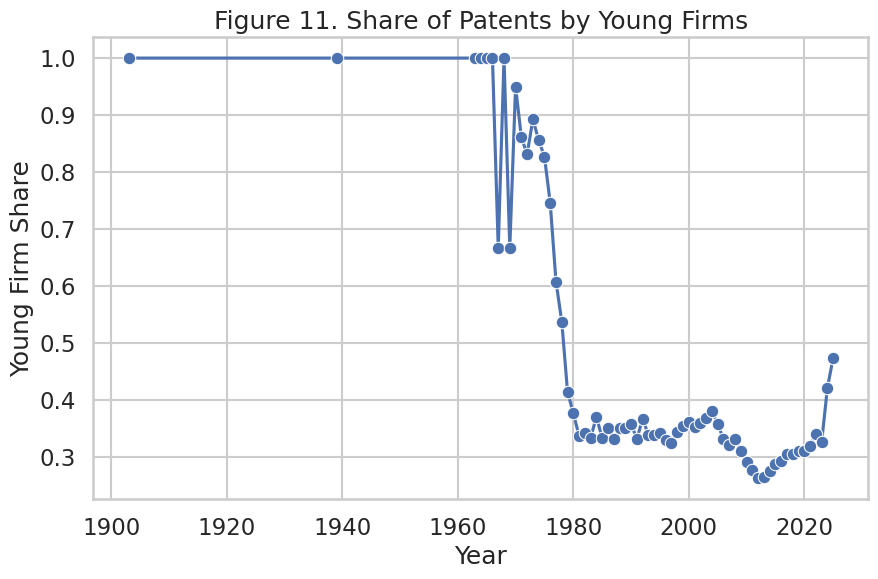

In [62]:
plt.figure()
sns.lineplot(data=yearly_young, x="filing_year", y="young_firm_share", marker="o")
plt.title("Figure 11. Share of Patents by Young Firms")
plt.xlabel("Year")
plt.ylabel("Young Firm Share")
plt.show()


Figure 12: Patent Concentration Over Time
This plots average top-4 concentration by year.

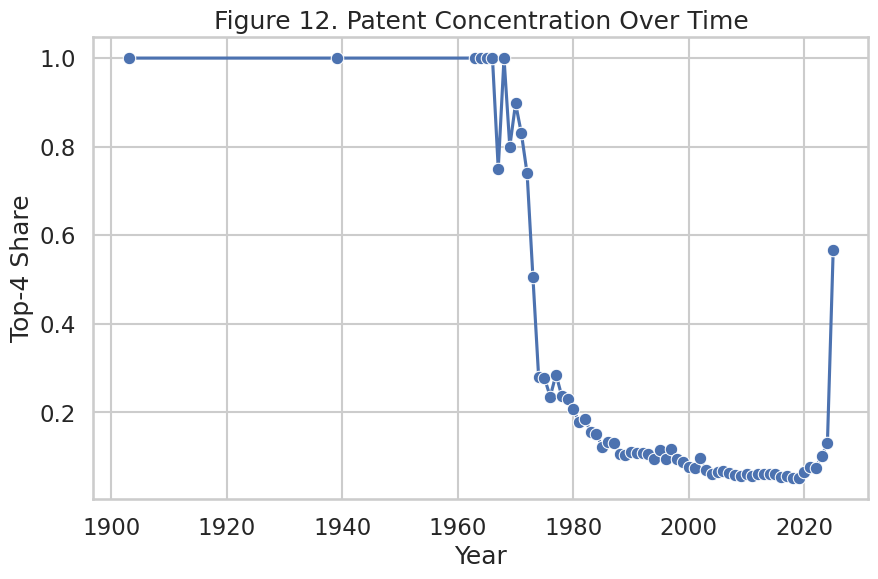

In [63]:
fig12 = panel.groupby("year")["concentration"].mean().reset_index()
plt.figure()
sns.lineplot(data=fig12, x="year", y="concentration", marker="o")
plt.title("Figure 12. Patent Concentration Over Time")
plt.xlabel("Year")
plt.ylabel("Top-4 Share")
plt.show()


Figure 13: Distribution of Firm Ages
This shows the distribution of patenting by firm age.

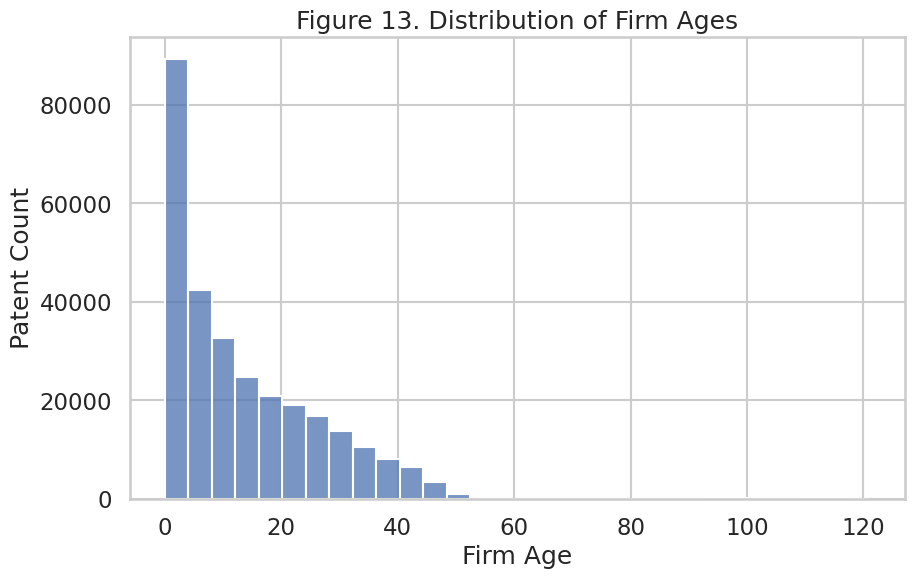

In [64]:
plt.figure(figsize=(10, 6))
sns.histplot(patent_level["firm_age"].dropna(), bins=30)
plt.title("Figure 13. Distribution of Firm Ages")
plt.xlabel("Firm Age")
plt.ylabel("Patent Count")
plt.show()


Figure 14: Incumbent vs Young Firm Patent Shares
This compares the yearly shares of young vs incumbent firms.

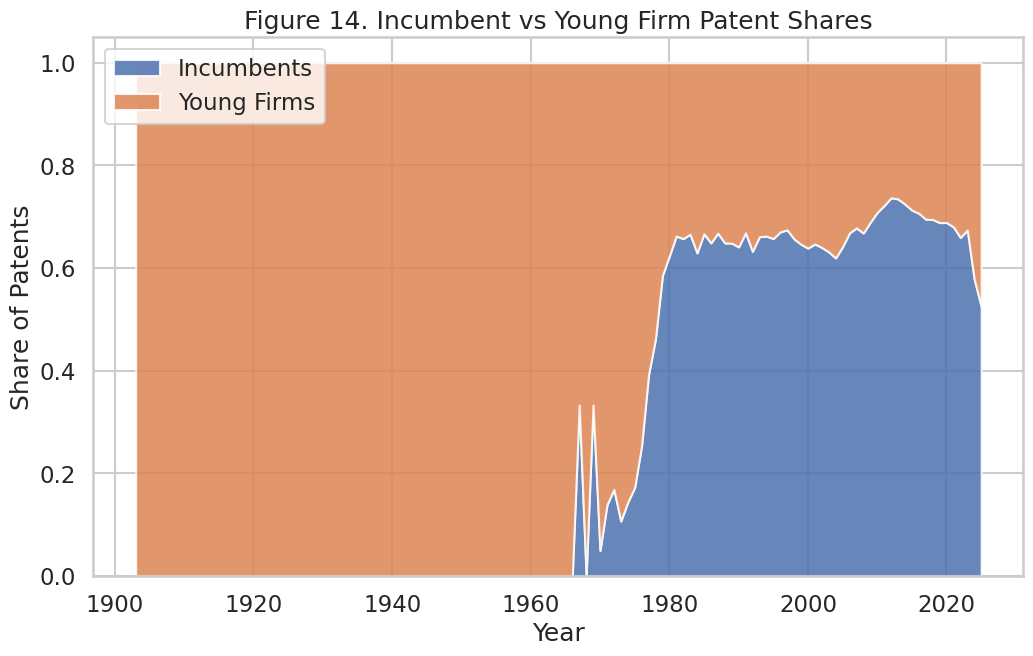

In [65]:
fig14 = patent_level.dropna(subset=["filing_year"]).copy()
fig14["firm_group"] = np.where(fig14["young_firm"] == 1, "Young Firms", "Incumbents")
fig14 = fig14.groupby(["filing_year", "firm_group"]).size().reset_index(name="n")
fig14["share"] = fig14["n"] / fig14.groupby("filing_year")["n"].transform("sum")
fig14p = fig14.pivot(index="filing_year", columns="firm_group", values="share").fillna(0)
plt.figure(figsize=(12, 7))
plt.stackplot(fig14p.index, fig14p.get("Incumbents", 0), fig14p.get("Young Firms", 0), labels=fig14p.columns, alpha=0.85)
plt.title("Figure 14. Incumbent vs Young Firm Patent Shares")
plt.xlabel("Year")
plt.ylabel("Share of Patents")
plt.legend(loc="upper left")
plt.show()


Figure 15: Entropy in High vs Low AI Areas
This is a simple visual diff-in-diff.

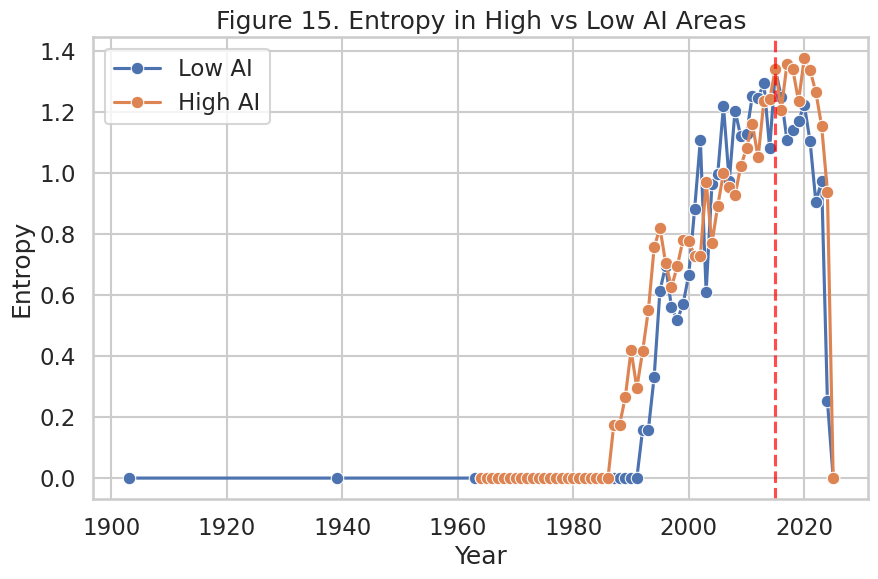

In [66]:
fig15 = panel.groupby(["year", "ai_group"])["entropy"].mean().reset_index()
plt.figure()
sns.lineplot(data=fig15, x="year", y="entropy", hue="ai_group", marker="o")
plt.axvline(2015, color="red", linestyle="--", alpha=0.7)
plt.title("Figure 15. Entropy in High vs Low AI Areas")
plt.xlabel("Year")
plt.ylabel("Entropy")
plt.legend(title="")
plt.show()


Figure 16: Event Study, AI and Target Diversity
This plots the high-minus-low entropy difference relative to 2015.

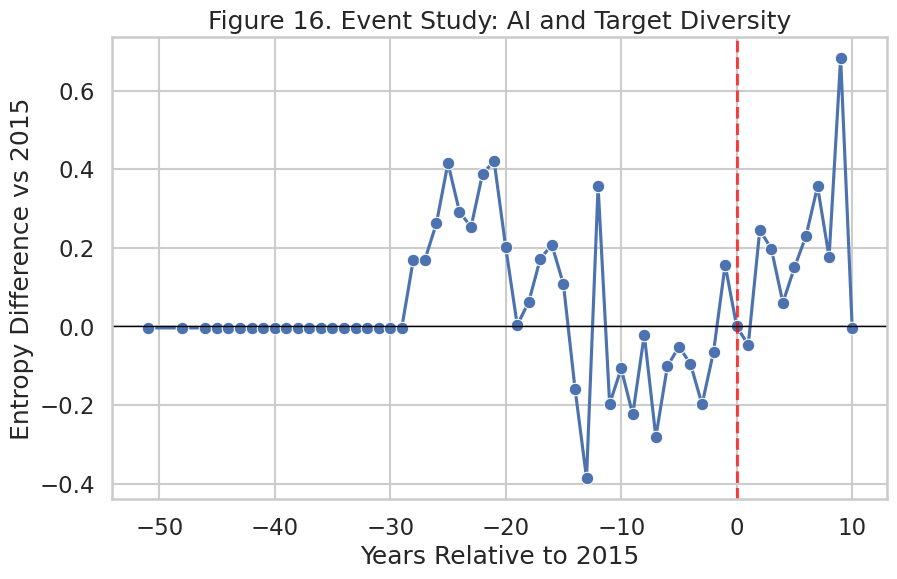

In [67]:
fig16 = panel.groupby(["year", "ai_group"])["entropy"].mean().reset_index()
fig16 = fig16.pivot(index="year", columns="ai_group", values="entropy").reset_index()
fig16["diff"] = fig16["High AI"] - fig16["Low AI"]
baseline = fig16.loc[fig16["year"] == 2015, "diff"].iloc[0]
fig16["event_time"] = fig16["year"] - 2015
fig16["diff_from_2015"] = fig16["diff"] - baseline

plt.figure()
sns.lineplot(data=fig16, x="event_time", y="diff_from_2015", marker="o")
plt.axvline(0, color="red", linestyle="--", alpha=0.7)
plt.axhline(0, color="black", linewidth=1)
plt.title("Figure 16. Event Study: AI and Target Diversity")
plt.xlabel("Years Relative to 2015")
plt.ylabel("Entropy Difference vs 2015")
plt.show()


Figure 17: Event Study, Young Firm Share
This does the same event-study style plot for young-firm share.

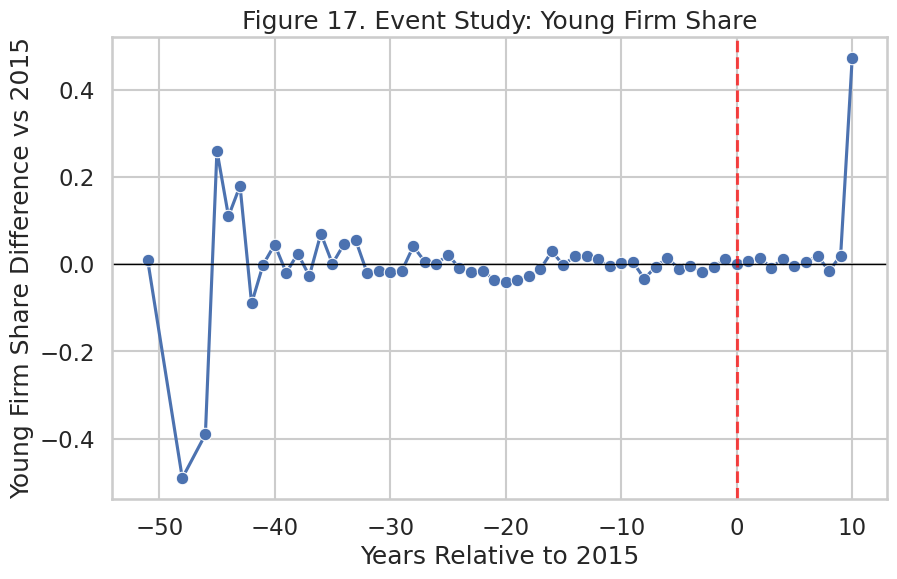

In [68]:
fig17 = panel.groupby(["year", "ai_group"])["young_firm_share"].mean().reset_index()
fig17 = fig17.pivot(index="year", columns="ai_group", values="young_firm_share").reset_index()
fig17["diff"] = fig17["High AI"] - fig17["Low AI"]
baseline = fig17.loc[fig17["year"] == 2015, "diff"].iloc[0]
fig17["event_time"] = fig17["year"] - 2015
fig17["diff_from_2015"] = fig17["diff"] - baseline

plt.figure()
sns.lineplot(data=fig17, x="event_time", y="diff_from_2015", marker="o")
plt.axvline(0, color="red", linestyle="--", alpha=0.7)
plt.axhline(0, color="black", linewidth=1)
plt.title("Figure 17. Event Study: Young Firm Share")
plt.xlabel("Years Relative to 2015")
plt.ylabel("Young Firm Share Difference vs 2015")
plt.show()


Figure 18: Event Study, Market Concentration
This does the event-study style plot for top-4 concentration.



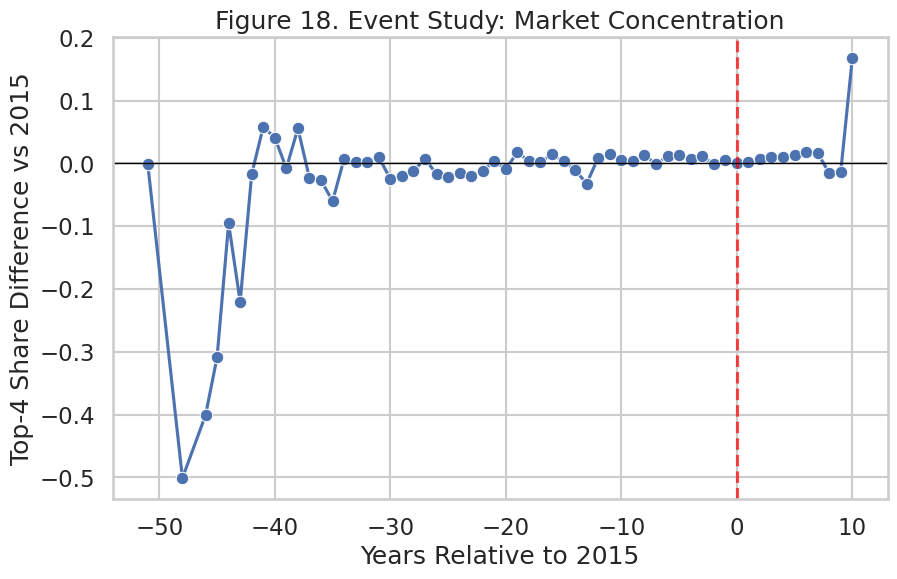

In [69]:
fig18 = panel.groupby(["year", "ai_group"])["concentration"].mean().reset_index()
fig18 = fig18.pivot(index="year", columns="ai_group", values="concentration").reset_index()
fig18["diff"] = fig18["High AI"] - fig18["Low AI"]
baseline = fig18.loc[fig18["year"] == 2015, "diff"].iloc[0]
fig18["event_time"] = fig18["year"] - 2015
fig18["diff_from_2015"] = fig18["diff"] - baseline

plt.figure()
sns.lineplot(data=fig18, x="event_time", y="diff_from_2015", marker="o")
plt.axvline(0, color="red", linestyle="--", alpha=0.7)
plt.axhline(0, color="black", linewidth=1)
plt.title("Figure 18. Event Study: Market Concentration")
plt.xlabel("Years Relative to 2015")
plt.ylabel("Top-4 Share Difference vs 2015")
plt.show()


Figure 19: Scientific Search Breadth vs Entry
This shows the cross-area-year relationship between entropy and young-firm share.

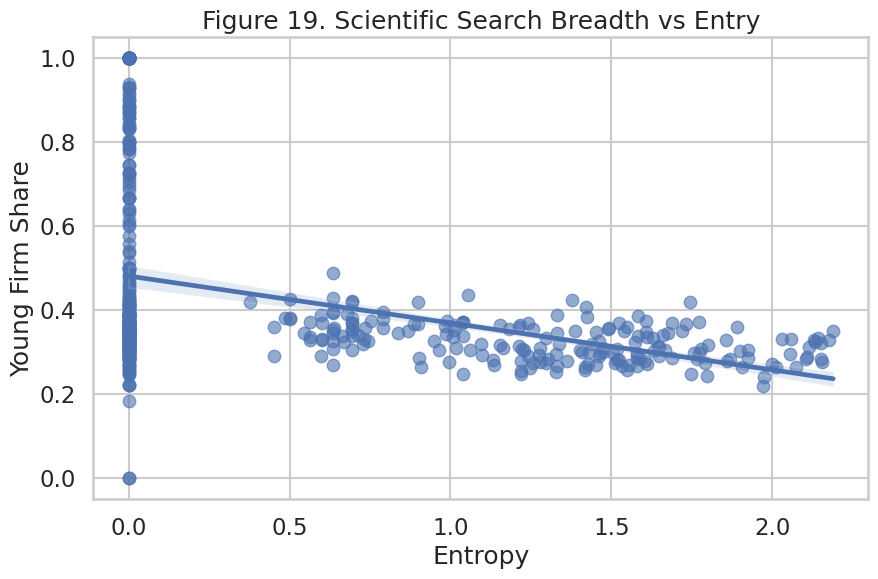

In [70]:
plt.figure()
sns.regplot(data=panel, x="entropy", y="young_firm_share", scatter_kws={"alpha": 0.6})
plt.title("Figure 19. Scientific Search Breadth vs Entry")
plt.xlabel("Entropy")
plt.ylabel("Young Firm Share")
plt.show()


Figure 20: Scientific Search Breadth vs Concentration
This shows the relationship between entropy and concentration.

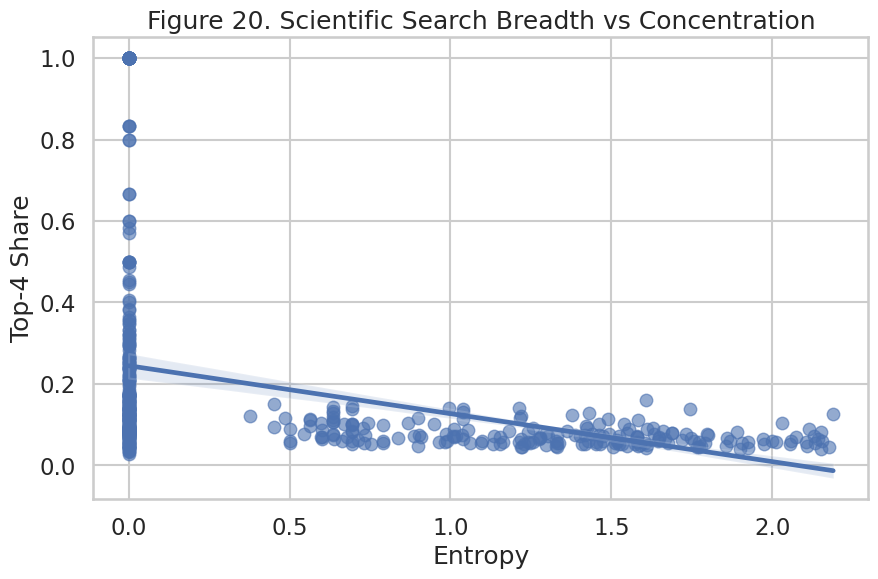

In [71]:
plt.figure()
sns.regplot(data=panel, x="entropy", y="concentration", scatter_kws={"alpha": 0.6})
plt.title("Figure 20. Scientific Search Breadth vs Concentration")
plt.xlabel("Entropy")
plt.ylabel("Top-4 Share")
plt.show()
